# DS605 - Fundamentals of Machine Learning
## Lab Assignment 5

### Machine Learning with Scikit-learn and From Scratch

Dataset: UCI Productivity Prediction of Garment Employees

In [139]:
import pandas as pd

In [140]:
df = pd.read_csv("garments_worker_productivity.csv")
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [141]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: float64(6), 

In [142]:
df.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(0)

In [144]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [145]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
team,1197.0,6.426901,3.463963,1.000000,3.000000,6.000000,9.000000,12.000000
targeted_productivity,1197.0,0.729632,0.097891,0.070000,0.700000,0.750000,0.800000,0.800000
smv,1197.0,15.062172,10.943219,2.900000,3.940000,15.260000,24.260000,54.560000
wip,691.0,1190.465991,1837.455001,7.000000,774.500000,1039.000000,1252.500000,23122.000000
over_time,1197.0,4567.460317,3348.823563,0.000000,1440.000000,3960.000000,6960.000000,25920.000000
incentive,1197.0,38.210526,160.182643,0.000000,0.000000,0.000000,50.000000,3600.000000
idle_time,1197.0,0.730159,12.709757,0.000000,0.000000,0.000000,0.000000,300.000000
idle_men,1197.0,0.369256,3.268987,0.000000,0.000000,0.000000,0.000000,45.000000
no_of_style_change,1197.0,0.150376,0.427848,0.000000,0.000000,0.000000,0.000000,2.000000
no_of_workers,1197.0,34.609858,22.197687,2.000000,9.000000,34.000000,57.000000,89.000000


In [146]:
print(df["department"].value_counts())

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64


In [147]:
print(df["quarter"].value_counts())

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64


In [148]:
print(df["day"].value_counts())

day
Wednesday    208
Sunday       203
Tuesday      201
Thursday     199
Monday       199
Saturday     187
Name: count, dtype: int64


In [149]:
for col in df.columns:
    print(col, ":", df[col].nunique())

date : 59
quarter : 5
department : 3
day : 6
team : 12
targeted_productivity : 9
smv : 70
wip : 548
over_time : 143
incentive : 48
idle_time : 12
idle_men : 10
no_of_style_change : 3
no_of_workers : 61
actual_productivity : 879


In [150]:
df["actual_productivity"].describe()

count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

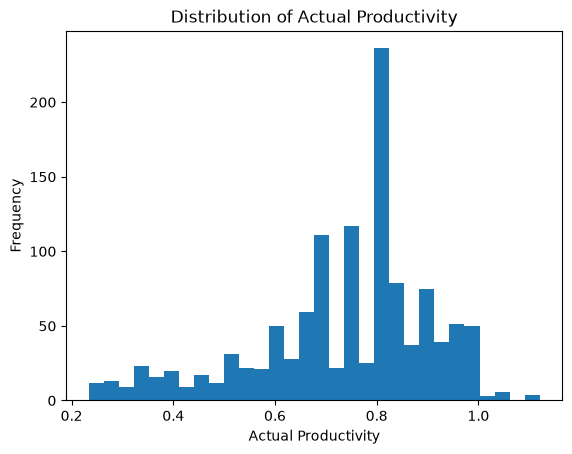

In [151]:
import matplotlib.pyplot as plt

plt.hist(df["actual_productivity"], bins=30)
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Productivity")
plt.show()

In [152]:
df.select_dtypes(include="number").corr()["actual_productivity"].sort_values()

no_of_style_change      -0.207366
idle_men                -0.181734
team                    -0.148753
smv                     -0.122089
idle_time               -0.080851
no_of_workers           -0.057991
over_time               -0.054206
incentive                0.076538
wip                      0.131147
targeted_productivity    0.421594
actual_productivity      1.000000
Name: actual_productivity, dtype: float64

In [153]:
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

In [154]:
df["MeetsTarget"].value_counts()

MeetsTarget
1    875
0    322
Name: count, dtype: int64

In [155]:
df["MeetsTarget"].value_counts(normalize=True) * 100

MeetsTarget
1    73.099415
0    26.900585
Name: proportion, dtype: float64

In [156]:
y_reg = df["actual_productivity"]

In [157]:
y_cls = df["MeetsTarget"]

In [158]:
X = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

In [159]:
print("X shape:", X.shape)
print("Regression target shape:", y_reg.shape)
print("Classification target shape:", y_cls.shape)

X shape: (1197, 14)
Regression target shape: (1197,)
Classification target shape: (1197,)


In [160]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['date', 'quarter', 'department', 'day']
Numerical: ['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


C:\Users\HP\AppData\Local\Temp\ipykernel_16004\4202884179.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [161]:
from sklearn.model_selection import train_test_split

In [162]:
reg_bins = pd.qcut(
    y_reg,
    q=5,
    labels=False,
    duplicates="drop"
)

In [163]:
combined_strata = (
    reg_bins.astype(str) + "_" +
    y_cls.astype(str)
)

In [164]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=combined_strata
)

In [165]:
combined_strata.value_counts()

4_1    240
3_1    239
2_1    214
0_0    178
1_1    120
1_0    119
0_1     62
2_0     25
Name: count, dtype: int64

In [166]:
X = df.drop(columns=["actual_productivity", "MeetsTarget"])

y_reg = df["actual_productivity"]
y_cls = df["MeetsTarget"]

In [167]:
X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()

In [168]:
y_reg_train = y_reg.loc[train_idx].copy()
y_reg_test = y_reg.loc[test_idx].copy()

In [169]:
y_cls_train = y_cls.loc[train_idx].copy()
y_cls_test = y_cls.loc[test_idx].copy()

In [170]:
print("Training inputs :", X_train.shape)
print("Testing inputs  :", X_test.shape)

print("Regression training target :", y_reg_train.shape)
print("Regression testing target  :", y_reg_test.shape)

print("Classification training target :", y_cls_train.shape)
print("Classification testing target  :", y_cls_test.shape)

Training inputs : (957, 14)
Testing inputs  : (240, 14)
Regression training target : (957,)
Regression testing target  : (240,)
Classification training target : (957,)
Classification testing target  : (240,)


In [171]:
print("Full dataset:")
print(y_cls.value_counts(normalize=True))

print("\nTraining set:")
print(y_cls_train.value_counts(normalize=True))

print("\nTesting set:")
print(y_cls_test.value_counts(normalize=True))

Full dataset:
MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64

Training set:
MeetsTarget
1    0.731452
0    0.268548
Name: proportion, dtype: float64

Testing set:
MeetsTarget
1    0.729167
0    0.270833
Name: proportion, dtype: float64


In [172]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [173]:
numeric_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

In [174]:
categorical_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

In [175]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [176]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [177]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [178]:
print("Before preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nAfter preprocessing:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

Before preprocessing:
X_train: (957, 14)
X_test : (240, 14)

After preprocessing:
X_train_processed: (957, 83)
X_test_processed : (240, 83)


# Linear Regression

In [179]:
from sklearn.linear_model import LinearRegression

In [180]:
linear_model = LinearRegression()
linear_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [181]:
import time

In [182]:
start_time = time.perf_counter()

linear_model.fit(
    X_train_processed,
    y_reg_train
)

linear_train_time = time.perf_counter() - start_time

In [183]:
start_time = time.perf_counter()

y_reg_pred = linear_model.predict(
    X_test_processed
)

linear_prediction_time = time.perf_counter() - start_time

In [184]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [185]:
mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

In [186]:
rmse = mean_squared_error(
    y_reg_test,
    y_reg_pred
) ** 0.5

In [187]:
r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

In [188]:
print("Linear Regression Results")

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

print("\nTraining time   :", linear_train_time)
print("Prediction time :", linear_prediction_time)

Linear Regression Results
MAE : 0.10268449818042943
RMSE: 0.14227762956486784
R²  : 0.27476138193488964

Training time   : 0.04608420003205538
Prediction time : 0.0036208999808877707


# Logistic Regression

In [189]:
from sklearn.linear_model import LogisticRegression

In [190]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [191]:
start_time = time.perf_counter()

logistic_model.fit(
    X_train_processed,
    y_cls_train
)

logistic_train_time = time.perf_counter() - start_time

In [192]:
start_time = time.perf_counter()

y_cls_pred = logistic_model.predict(
    X_test_processed
)

logistic_prediction_time = time.perf_counter() - start_time

In [193]:
print("Actual values:")
print(y_cls_test.head(10).values)

print("\nPredicted values:")
print(y_cls_pred[:10])

Actual values:
[1 1 0 0 0 1 0 1 1 0]

Predicted values:
[1 1 1 1 0 1 0 1 1 0]


In [194]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [195]:
accuracy = accuracy_score(
    y_cls_test,
    y_cls_pred
)

precision = precision_score(
    y_cls_test,
    y_cls_pred
)

recall = recall_score(
    y_cls_test,
    y_cls_pred
)

f1 = f1_score(
    y_cls_test,
    y_cls_pred
)

In [196]:
print("Logistic Regression Results")


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nTraining time   :", logistic_train_time)
print("Prediction time :", logistic_prediction_time)

Logistic Regression Results
Accuracy : 0.75
Precision: 0.7725118483412322
Recall   : 0.9314285714285714
F1-score : 0.844559585492228

Training time   : 0.1385757999960333
Prediction time : 0.002047699992544949


In [197]:
regression_results = pd.DataFrame({
    "Model": ["Scikit-learn Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Training Time (s)": [linear_train_time],
    "Prediction Time (s)": [linear_prediction_time]
})

regression_results

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn Linear Regression,0.102684,0.142278,0.274761,0.046084,0.003621


In [198]:
classification_results = pd.DataFrame({
    "Model": ["Scikit-learn Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1],
    "Training Time (s)": [logistic_train_time],
    "Prediction Time (s)": [logistic_prediction_time]
})

classification_results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn Logistic Regression,0.75,0.772512,0.931429,0.84456,0.138576,0.002048


### Part B

In [199]:
import numpy as np
import pandas as pd
import time

In [200]:
X_manual = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

y_reg_manual = df["actual_productivity"]
y_cls_manual = df["MeetsTarget"]

In [201]:
X_train_manual = X_manual.loc[train_idx].copy()
X_test_manual = X_manual.loc[test_idx].copy()

y_reg_train_manual = y_reg_manual.loc[train_idx].copy()
y_reg_test_manual = y_reg_manual.loc[test_idx].copy()

y_cls_train_manual = y_cls_manual.loc[train_idx].copy()
y_cls_test_manual = y_cls_manual.loc[test_idx].copy()

In [202]:
categorical_manual = X_train_manual.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_manual = X_train_manual.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_manual)

print("\nNumerical columns:")
print(numerical_manual)

Categorical columns:
['date', 'quarter', 'department', 'day']

Numerical columns:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


C:\Users\HP\AppData\Local\Temp\ipykernel_16004\639286892.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_manual = X_train_manual.select_dtypes(


In [203]:
train_medians = X_train_manual[numerical_manual].median()

train_medians

team                        7.00
targeted_productivity       0.75
smv                        15.26
wip                      1038.00
over_time                4080.00
incentive                   0.00
idle_time                   0.00
idle_men                    0.00
no_of_style_change          0.00
no_of_workers              34.00
dtype: float64

In [204]:
X_train_manual[numerical_manual] = (
    X_train_manual[numerical_manual]
    .fillna(train_medians)
)

X_test_manual[numerical_manual] = (
    X_test_manual[numerical_manual]
    .fillna(train_medians)
)

In [205]:
print(
    X_train_manual[numerical_manual]
    .isnull()
    .sum()
)

team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
dtype: int64


# one-hot encoding

In [206]:
train_modes = X_train_manual[categorical_manual].mode().iloc[0]

train_modes

date          3/11/2015
quarter        Quarter2
department       sweing
day              Monday
Name: 0, dtype: str

In [207]:
X_train_manual[categorical_manual] = (
    X_train_manual[categorical_manual]
    .fillna(train_modes)
)

X_test_manual[categorical_manual] = (
    X_test_manual[categorical_manual]
    .fillna(train_modes)
)

In [208]:
print(
    X_train_manual[categorical_manual]
    .isnull()
    .sum()
)

date          0
quarter       0
department    0
day           0
dtype: int64


In [209]:
X_train_encoded = pd.get_dummies(
    X_train_manual,
    columns=categorical_manual,
    dtype=float
)

In [210]:
X_test_encoded = pd.get_dummies(
    X_test_manual,
    columns=categorical_manual,
    dtype=float
)

In [211]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [212]:
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (957, 83)
Encoded testing shape : (240, 83)


# feature scaling

In [213]:
manual_means = X_train_manual[numerical_manual].mean()

manual_means

team                        6.532915
targeted_productivity       0.728495
smv                        15.065371
wip                      1122.359457
over_time                4580.381400
incentive                  38.696970
idle_time                   0.907001
idle_men                    0.430512
no_of_style_change          0.161964
no_of_workers              34.496865
dtype: float64

In [214]:
manual_stds = X_train_manual[numerical_manual].std()

manual_stds

team                        3.442020
targeted_productivity       0.098471
smv                        11.047544
wip                      1385.738699
over_time                3352.079350
incentive                 173.303161
idle_time                  14.209661
idle_men                    3.582067
no_of_style_change          0.445685
no_of_workers              22.117554
dtype: float64

In [215]:
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

In [216]:
X_train_scaled[numerical_manual] = (
    X_train_scaled[numerical_manual] - manual_means
) / manual_stds

X_test_scaled[numerical_manual] = (
    X_test_scaled[numerical_manual] - manual_means
) / manual_stds

In [217]:
X_train_scaled.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter5,department_finishing,department_finishing,department_sweing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
402,-1.607462,-0.289378,0.712795,0.252313,1.694357,0.209477,-0.06383,-0.120185,-0.363405,1.017433,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
323,0.716755,0.726152,1.004262,0.053142,1.801753,0.140234,-0.06383,-0.120185,-0.363405,1.107859,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1159,-1.026407,0.726152,1.360902,-0.264378,0.709893,0.140234,-0.06383,-0.120185,1.880330,1.062646,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1044,-0.445353,-0.289378,-0.947303,-0.060877,-0.364067,-0.223291,-0.06383,-0.120185,-0.363405,-1.198002,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
449,1.588336,-0.289378,-0.994372,-0.060877,-0.883148,-0.223291,-0.06383,-0.120185,-0.363405,-1.152789,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [218]:
X_train_np = X_train_scaled.to_numpy(dtype=float)
X_test_np = X_test_scaled.to_numpy(dtype=float)

y_reg_train_np = y_reg_train_manual.to_numpy(dtype=float)
y_reg_test_np = y_reg_test_manual.to_numpy(dtype=float)

In [219]:
print("X_train_np:", X_train_np.shape)
print("X_test_np :", X_test_np.shape)
print("y_train   :", y_reg_train_np.shape)
print("y_test    :", y_reg_test_np.shape)

X_train_np: (957, 83)
X_test_np : (240, 83)
y_train   : (957,)
y_test    : (240,)


# Linear Regression

In [220]:
X_train_design = np.column_stack([
    np.ones(X_train_np.shape[0]),
    X_train_np
])

X_test_design = np.column_stack([
    np.ones(X_test_np.shape[0]),
    X_test_np
])

In [221]:
print("Before intercept:", X_train_np.shape)
print("After intercept :", X_train_design.shape)

Before intercept: (957, 83)
After intercept : (957, 84)


In [222]:
start_time = time.perf_counter()

XtX = X_train_design.T @ X_train_design
Xty = X_train_design.T @ y_reg_train_np

beta = np.linalg.solve(XtX, Xty)

linear_manual_train_time = time.perf_counter() - start_time

In [223]:
print(beta)

[ 6.95072672e+00 -2.49117895e-02  6.96888711e-02 -7.36856484e-02
  1.55395348e-02 -4.41924987e-03  1.23907557e-02  5.93171656e-03
 -3.18159621e-02 -1.36374750e-02  9.36789202e-02  8.64530274e+00
 -1.16064628e+01  4.83908907e+00 -1.41968062e+01  2.96767820e+00
  5.81137492e+00  2.10382420e+01 -2.82246593e+00  1.35964886e+01
 -5.39661249e+00  1.17546176e+01  1.46111859e+01  1.72612933e+01
 -6.48288098e+00  1.00374928e+01 -8.99965650e+00  8.18685265e+00
  1.09931755e+01  2.25872147e+01 -1.50893729e+01 -1.11177833e+00
  1.34957652e+00 -1.76790523e+01 -5.05866643e-01  2.29369888e+00
  1.22011476e+01  1.38389511e+00  3.02219520e+00  5.90833856e+00
  1.22055232e+01 -1.15993604e+01  1.36331048e+01 -5.38075512e+00
  1.18448714e+01  1.46357427e+01  2.09969284e+01 -1.78045154e+01
  9.96118298e+00 -9.08719083e+00  8.07483174e+00  1.09722149e+01
  1.72513171e+01 -6.52078643e+00 -5.06575544e-01  2.36342533e+00
  8.80705284e+00 -1.50752518e+01  4.86500014e+00 -1.41689516e+01
  1.34920535e+00  3.04301

In [224]:
start_time = time.perf_counter()

y_reg_pred_manual = X_test_design @ beta

linear_manual_prediction_time = (
    time.perf_counter() - start_time
)

In [225]:
print("Actual values:")
print(y_reg_test_np[:10])

print("\nPredicted values:")
print(y_reg_pred_manual[:10])

Actual values:
[0.60036969 0.80034377 0.49654971 0.3715625  0.60958333 0.80007184
 0.4731348  0.90083333 0.81337121 0.68402778]

Predicted values:
[0.66986972 0.77400572 0.81451417 0.72605901 0.70845778 0.76881676
 0.61116905 0.84334511 0.80427547 0.72705349]


In [226]:
errors = y_reg_test_np - y_reg_pred_manual

In [227]:
mae_manual = np.mean(
    np.abs(errors)
)

In [228]:
rmse_manual = np.sqrt(
    np.mean(errors ** 2)
)

In [229]:
ss_res = np.sum(
    (y_reg_test_np - y_reg_pred_manual) ** 2
)

ss_tot = np.sum(
    (y_reg_test_np - np.mean(y_reg_test_np)) ** 2
)

r2_manual = 1 - (ss_res / ss_tot)

In [230]:
print("From Scratch Linear Regression")

print("MAE :", mae_manual)
print("RMSE:", rmse_manual)
print("R²  :", r2_manual)

print("\nTraining time   :", linear_manual_train_time)
print("Prediction time :", linear_manual_prediction_time)

From Scratch Linear Regression
MAE : 0.10268453177868211
RMSE: 0.1422777224859943
R²  : 0.274760434631908

Training time   : 0.03778269997565076
Prediction time : 0.0012076000566594303


# Linear Regression comparison table

In [231]:
regression_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    "MAE": [
        mae,
        mae_manual
    ],
    "RMSE": [
        rmse,
        rmse_manual
    ],
    "R2": [
        r2,
        r2_manual
    ],
    "Training Time (s)": [
        linear_train_time,
        linear_manual_train_time
    ],
    "Prediction Time (s)": [
        linear_prediction_time,
        linear_manual_prediction_time
    ]
})

regression_comparison.round(6)

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.102684,0.142278,0.274761,0.046084,0.003621
1,From Scratch,0.102685,0.142278,0.274760,0.037783,0.001208


### Linear Regression Comparison

The Scikit-learn and from-scratch Linear Regression models produced almost identical MAE, RMSE, and R² values. This shows that the manual NumPy implementation successfully reproduces the behaviour of Scikit-learn Linear Regression.

Small differences in execution time are expected because the dataset is relatively small and timing can vary between runs.

In [232]:
y_cls_train_np = y_cls_train_manual.to_numpy(dtype=float)
y_cls_test_np = y_cls_test_manual.to_numpy(dtype=float)

### Initialize the parameters

In [233]:
beta_log = np.zeros(
    X_train_design.shape[1]
)

print(beta_log.shape)

(84,)


In [234]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [235]:
print(
    sigmoid(
        np.array([-3, -1, 0, 1, 3])
    )
)

[0.04742587 0.26894142 0.5        0.73105858 0.95257413]


In [236]:
def predict_probability(X, beta):
    z = X @ beta
    return sigmoid(z)

In [237]:
train_probabilities = predict_probability(
    X_train_design,
    beta_log
)

print(train_probabilities[:10])

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [238]:
def predict_class(probabilities, threshold=0.5):
    return (probabilities >= threshold).astype(int)

In [239]:
initial_classes = predict_class(
    train_probabilities
)

print(initial_classes[:10])

[1 1 1 1 1 1 1 1 1 1]


In [240]:
def log_loss(y, probabilities):
    eps = 1e-15

    probabilities = np.clip(
        probabilities,
        eps,
        1 - eps
    )

    loss = -np.mean(
        y * np.log(probabilities)
        +
        (1 - y) * np.log(1 - probabilities)
    )

    return loss

In [241]:
initial_loss = log_loss(
    y_cls_train_np,
    train_probabilities
)

print("Initial Loss:", initial_loss)

Initial Loss: 0.6931471805599452


### Calculate the gradient

In [242]:
def compute_gradient(X, y, probabilities):
    n = X.shape[0]

    gradient = (
        X.T @ (probabilities - y)
    ) / n

    return gradient

### Gradient Descent training loop

In [243]:
def train_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    n_iterations=1000
):
    beta = np.zeros(X.shape[1])

    for i in range(n_iterations):

        probabilities = predict_probability(
            X,
            beta
        )

        gradient = compute_gradient(
            X,
            y,
            probabilities
        )

        beta = beta - learning_rate * gradient

    return beta

In [244]:
start_time = time.perf_counter()

beta_log = train_logistic_regression(
    X_train_design,
    y_cls_train_np,
    learning_rate=0.01,
    n_iterations=1000
)

logistic_manual_train_time = (
    time.perf_counter() - start_time
)

In [245]:
print(beta_log)

[ 5.35209257e-01 -1.21573383e-01  4.49457213e-03 -5.50367663e-02
  1.20406133e-01  7.55300135e-02  1.16537526e-01 -3.32520754e-02
 -3.03050600e-01 -6.39330702e-02  2.85766310e-01 -9.87309338e-03
  1.34020026e-02  9.07899411e-03  3.39545089e-03  9.74803413e-03
  1.67389960e-02  1.16446762e-02  1.55291172e-02  6.73127303e-03
  4.66645076e-03  9.02597635e-03  1.38019194e-02 -2.02886299e-02
  8.08083080e-03  2.89257592e-02  3.35917807e-02  3.50732008e-02
  1.48803387e-02  2.67403187e-02  1.61126921e-02  5.82649639e-02
 -4.18924944e-04  4.83673683e-02  1.85006592e-02  1.44716460e-02
  1.41964275e-02  1.66616928e-02  1.65028542e-02  1.90357918e-02
 -1.73502537e-02  4.79966218e-03 -2.67443360e-02 -1.31878568e-02
  2.00455810e-02  5.47867593e-04 -3.04526476e-02 -7.94681767e-03
 -2.21195789e-02  9.77714612e-03 -1.45971471e-03  8.51163705e-03
 -1.58564692e-02 -4.41943569e-03  6.37710587e-05  6.51829465e-03
  1.91527326e-02 -1.50764761e-04 -8.70686016e-03  4.31617096e-03
  2.26390218e-03  4.68368

In [246]:
start_time = time.perf_counter()

y_cls_prob_manual = predict_probability(
    X_test_design,
    beta_log
)

logistic_manual_prediction_time = (
    time.perf_counter() - start_time
)

In [247]:
y_cls_pred_manual = predict_class(
    y_cls_prob_manual,
    threshold=0.5
)

In [248]:
print("Actual:")
print(y_cls_test_np[:20].astype(int))

print("\nPredicted:")
print(y_cls_pred_manual[:20])

print("\nProbabilities:")
print(y_cls_prob_manual[:20])

Actual:
[1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 0]

Predicted:
[1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Probabilities:
[0.85146592 0.80287157 0.81691221 0.5633392  0.490352   0.8441615
 0.83381929 0.65591464 0.68629863 0.55560795 0.85483777 0.80518621
 0.85090873 0.77526948 0.61983695 0.83158674 0.5677409  0.57001259
 0.79495419 0.63301291]


### classification metrics

In [249]:
tp = np.sum(
    (y_cls_test_np == 1) &
    (y_cls_pred_manual == 1)
)

tn = np.sum(
    (y_cls_test_np == 0) &
    (y_cls_pred_manual == 0)
)

fp = np.sum(
    (y_cls_test_np == 0) &
    (y_cls_pred_manual == 1)
)

fn = np.sum(
    (y_cls_test_np == 1) &
    (y_cls_pred_manual == 0)
)

In [250]:
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 175
TN: 2
FP: 63
FN: 0


In [251]:
accuracy_manual = (
    (tp + tn) /
    (tp + tn + fp + fn)
)

In [252]:
if (tp + fp) == 0:
    precision_manual = 0.0
else:
    precision_manual = tp / (tp + fp)

In [253]:
if (tp + fn) == 0:
    recall_manual = 0.0
else:
    recall_manual = tp / (tp + fn)

In [254]:
if (precision_manual + recall_manual) == 0:
    f1_manual = 0.0
else:
    f1_manual = (
        2
        * precision_manual
        * recall_manual
        / (precision_manual + recall_manual)
    )

In [255]:
print("From-Scratch Logistic Regression")

print("Accuracy :", accuracy_manual)
print("Precision:", precision_manual)
print("Recall   :", recall_manual)
print("F1-score :", f1_manual)

print("\nTraining time   :", logistic_manual_train_time)
print("Prediction time :", logistic_manual_prediction_time)

From-Scratch Logistic Regression
Accuracy : 0.7375
Precision: 0.7352941176470589
Recall   : 1.0
F1-score : 0.8474576271186441

Training time   : 0.18206780002219602
Prediction time : 0.0006048999493941665


### Logistic Regression comparison table

In [256]:
classification_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    "Accuracy": [
        accuracy,
        accuracy_manual
    ],
    "Precision": [
        precision,
        precision_manual
    ],
    "Recall": [
        recall,
        recall_manual
    ],
    "F1-Score": [
        f1,
        f1_manual
    ],
    "Training Time (s)": [
        logistic_train_time,
        logistic_manual_train_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        logistic_manual_prediction_time
    ]
})

classification_comparison.round(6)

,Implementation,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.7500,0.772512,0.931429,0.844560,0.138576,0.002048
1,From Scratch,0.7375,0.735294,1.000000,0.847458,0.182068,0.000605


### Logistic Regression Comparison

The Scikit-learn and from-scratch Logistic Regression models were evaluated using the same train-test split and the same input features.

Any difference in accuracy, precision, recall, F1-score, or runtime is due to differences in the implementation and optimization process used by the two models.

### Part C - Comparison and Optimization

In [257]:
def train_logistic_regression_optimized(
    X,
    y,
    learning_rate=0.01,
    max_iterations=20000,
    tolerance=1e-6
):
    beta = np.zeros(X.shape[1])

    previous_loss = float("inf")

    for i in range(max_iterations):

        probabilities = predict_probability(
            X,
            beta
        )

        gradient = compute_gradient(
            X,
            y,
            probabilities
        )

        beta = beta - learning_rate * gradient

        new_probabilities = predict_probability(
            X,
            beta
        )

        current_loss = log_loss(
            y,
            new_probabilities
        )

        loss_change = abs(
            previous_loss - current_loss
        )

        if loss_change < tolerance:
            return (
                beta,
                i + 1,
                current_loss,
                loss_change,
                True
            )

        previous_loss = current_loss

    return (
        beta,
        max_iterations,
        current_loss,
        loss_change,
        False
    )

In [258]:
start_time = time.perf_counter()

beta_opt, iterations_used, final_loss = (
    train_logistic_regression_optimized(
        X_train_design,
        y_cls_train_np,
        learning_rate=0.01,
        max_iterations=5000,
        tolerance=1e-7
    )
)

optimized_train_time = (
    time.perf_counter() - start_time
)

print("Iterations used:", iterations_used)
print("Final loss:", final_loss)
print("Training time:", optimized_train_time)

ValueError: too many values to unpack (expected 3, got 5)

In [ ]:
learning_rates = [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1
]

In [ ]:
optimization_results = []

for lr in learning_rates:

    start_time = time.perf_counter()

    beta_temp, iterations_used, final_loss = (
        train_logistic_regression_optimized(
            X_train_design,
            y_cls_train_np,
            learning_rate=lr,
            max_iterations=5000,
            tolerance=1e-7
        )
    )

    train_time = time.perf_counter() - start_time

    probabilities = predict_probability(
        X_test_design,
        beta_temp
    )

    predictions = predict_class(
        probabilities,
        threshold=0.5
    )

    tp_temp = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 1)
    )

    tn_temp = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 0)
    )

    fp_temp = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 1)
    )

    fn_temp = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 0)
    )

    accuracy_temp = (
        (tp_temp + tn_temp) /
        (tp_temp + tn_temp + fp_temp + fn_temp)
    )

    precision_temp = (
        tp_temp / (tp_temp + fp_temp)
        if (tp_temp + fp_temp) != 0
        else 0
    )

    recall_temp = (
        tp_temp / (tp_temp + fn_temp)
        if (tp_temp + fn_temp) != 0
        else 0
    )

    f1_temp = (
        2 * precision_temp * recall_temp
        / (precision_temp + recall_temp)
        if (precision_temp + recall_temp) != 0
        else 0
    )

    optimization_results.append({
        "Learning Rate": lr,
        "Iterations": iterations_used,
        "Accuracy": accuracy_temp,
        "Precision": precision_temp,
        "Recall": recall_temp,
        "F1-Score": f1_temp,
        "Training Time": train_time
    })

In [ ]:
optimization_results_df = pd.DataFrame(
    optimization_results
)

optimization_results_df.round(6)

,Learning Rate,Iterations,Accuracy,Precision,Recall,F1-Score,Training Time
0,0.001,5000,0.733333,0.732218,1.000000,0.845411,1.323994
1,0.005,5000,0.750000,0.748918,0.988571,0.852217,0.505137
2,0.010,5000,0.754167,0.756637,0.977143,0.852868,0.488679
3,0.050,5000,0.754167,0.773585,0.937143,0.847545,0.571138
4,0.100,5000,0.754167,0.776190,0.931429,0.846753,0.492974


### Learning Rate Optimization

Different learning rates were tested for the from-scratch Logistic Regression model.

A learning rate of 0.01 produced the highest F1-score among the tested values while also improving accuracy compared with the original manual model.

The original manual model achieved an accuracy of 0.7375 and an F1-score of 0.8475, whereas the tuned model achieved approximately 0.7542 accuracy and 0.8529 F1-score.

All tested configurations reached the maximum of 5000 iterations, so the convergence stopping condition was not triggered.

In [ ]:
start_time = time.perf_counter()

(
    beta_optimized,
    optimized_iterations,
    optimized_loss,
    optimized_loss_change,
    optimized_converged
) = train_logistic_regression_optimized(
    X_train_design,
    y_cls_train_np,
    learning_rate=0.01,
    max_iterations=20000,
    tolerance=1e-6
)

optimized_logistic_train_time = (
    time.perf_counter() - start_time
)

print("Converged:", optimized_converged)
print("Iterations used:", optimized_iterations)
print("Final loss:", optimized_loss)
print("Final loss change:", optimized_loss_change)
print("Training time:", optimized_logistic_train_time)

Converged: True
Iterations used: 12759
Final loss: 0.48105634560487265
Final loss change: 9.998879719752551e-07
Training time: 7.832503099984024


In [ ]:
start_time = time.perf_counter()

optimized_probabilities = predict_probability(
    X_test_design,
    beta_optimized
)

optimized_predictions = predict_class(
    optimized_probabilities,
    threshold=0.5
)

optimized_logistic_prediction_time = (
    time.perf_counter() - start_time
)

In [ ]:
tp_opt = np.sum(
    (y_cls_test_np == 1) &
    (optimized_predictions == 1)
)

tn_opt = np.sum(
    (y_cls_test_np == 0) &
    (optimized_predictions == 0)
)

fp_opt = np.sum(
    (y_cls_test_np == 0) &
    (optimized_predictions == 1)
)

fn_opt = np.sum(
    (y_cls_test_np == 1) &
    (optimized_predictions == 0)
)

accuracy_opt = (
    (tp_opt + tn_opt) /
    (tp_opt + tn_opt + fp_opt + fn_opt)
)

precision_opt = (
    tp_opt / (tp_opt + fp_opt)
    if (tp_opt + fp_opt) != 0
    else 0
)

recall_opt = (
    tp_opt / (tp_opt + fn_opt)
    if (tp_opt + fn_opt) != 0
    else 0
)

f1_opt = (
    2 * precision_opt * recall_opt
    / (precision_opt + recall_opt)
    if (precision_opt + recall_opt) != 0
    else 0
)

In [ ]:
final_classification_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual Original",
        "Manual Optimized"
    ],
    "Accuracy": [
        accuracy,
        accuracy_manual,
        accuracy_opt
    ],
    "Precision": [
        precision,
        precision_manual,
        precision_opt
    ],
    "Recall": [
        recall,
        recall_manual,
        recall_opt
    ],
    "F1-Score": [
        f1,
        f1_manual,
        f1_opt
    ],
    "Training Time (s)": [
        logistic_train_time,
        logistic_manual_train_time,
        optimized_logistic_train_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        logistic_manual_prediction_time,
        optimized_logistic_prediction_time
    ]
})

final_classification_comparison.round(6)

,Implementation,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.750000,0.772512,0.931429,0.844560,0.188518,0.003126
1,Manual Original,0.737500,0.735294,1.000000,0.847458,0.291376,0.002041
2,Manual Optimized,0.754167,0.756637,0.977143,0.852868,1.988596,0.001645


### Final Classification Comparison

The optimized manual Logistic Regression model improved over the original manual implementation.

The original manual model achieved an accuracy of 0.7375 and an F1-score of 0.8475. After tuning the learning rate and increasing the number of iterations, the optimized manual model achieved an accuracy of approximately 0.7542 and an F1-score of approximately 0.8529.

The optimized manual model also achieved a slightly higher F1-score than the Scikit-learn Logistic Regression model in this experiment.

However, the optimized manual implementation required substantially more training time because gradient descent was performed manually for many iterations. Scikit-learn remained much faster for model training.

Therefore, the optimization improved predictive performance, but increased computational cost.

### Final Regression Comparison

The Scikit-learn and from-scratch Linear Regression models produced almost identical MAE, RMSE, and R² values.

This indicates that the manual closed-form NumPy implementation successfully reproduced the behaviour of Scikit-learn Linear Regression.

No further model-level optimization was necessary for Linear Regression because the predictive performance was already nearly identical.

In [ ]:
start_time = time.perf_counter()

converged_probabilities = predict_probability(
    X_test_design,
    beta_optimized
)

converged_predictions = predict_class(
    converged_probabilities,
    threshold=0.5
)

converged_prediction_time = (
    time.perf_counter() - start_time
)

In [ ]:
tp_conv = np.sum(
    (y_cls_test_np == 1) &
    (converged_predictions == 1)
)

tn_conv = np.sum(
    (y_cls_test_np == 0) &
    (converged_predictions == 0)
)

fp_conv = np.sum(
    (y_cls_test_np == 0) &
    (converged_predictions == 1)
)

fn_conv = np.sum(
    (y_cls_test_np == 1) &
    (converged_predictions == 0)
)

accuracy_conv = (
    (tp_conv + tn_conv) /
    (tp_conv + tn_conv + fp_conv + fn_conv)
)

precision_conv = (
    tp_conv / (tp_conv + fp_conv)
    if (tp_conv + fp_conv) != 0
    else 0
)

recall_conv = (
    tp_conv / (tp_conv + fn_conv)
    if (tp_conv + fn_conv) != 0
    else 0
)

f1_conv = (
    2 * precision_conv * recall_conv
    / (precision_conv + recall_conv)
    if (precision_conv + recall_conv) != 0
    else 0
)

print("Converged Logistic Regression Results")

print("Accuracy :", accuracy_conv)
print("Precision:", precision_conv)
print("Recall   :", recall_conv)
print("F1-score :", f1_conv)

print("\nIterations      :", optimized_iterations)
print("Training time   :", optimized_logistic_train_time)
print("Prediction time :", converged_prediction_time)

Converged Logistic Regression Results
Accuracy : 0.7458333333333333
Precision: 0.759090909090909
Recall   : 0.9542857142857143
F1-score : 0.8455696202531645

Iterations      : 12759
Training time   : 7.832503099984024
Prediction time : 0.02387470001121983


### Convergence Experiment

A stricter convergence experiment was also performed by allowing up to 20,000 iterations with a tolerance of 1e-6.

The model converged after 12,759 iterations. However, convergence did not improve test performance. The converged model achieved an accuracy of approximately 0.7458 and an F1-score of approximately 0.8456, while requiring substantially more training time.

The 5,000-iteration model with a learning rate of 0.01 achieved better accuracy and F1-score with much lower training time. Therefore, the 5,000-iteration configuration was retained as the final optimized manual Logistic Regression model.